# 02 — Modelo preentrenado de análisis de sentimiento

Este notebook aplica `pysentimiento`, un modelo preentrenado para tareas de sentimiento en español, al corpus completo de tweets institucionales. No se entrena un modelo supervisado propio ni se calculan métricas como accuracy, precision, recall o F1 porque no existe una muestra etiquetada manualmente de referencia.

In [ ]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.modeling_utils import cargar_analizador_pysentimiento, predecir_sentimiento, resumen_distribucion
from src.text_utils import limpiar_texto_suave, validar_columnas

DATA_INPUT = PROJECT_ROOT / "data" / "input"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
OUTPUTS_FIG = PROJECT_ROOT / "outputs" / "figures"
OUTPUTS_TABLES = PROJECT_ROOT / "outputs" / "tables"

for p in [DATA_PROCESSED, OUTPUTS_FIG, OUTPUTS_TABLES]:
    p.mkdir(parents=True, exist_ok=True)

TWEETS_INPUT = DATA_INPUT / "tweets_limpios_2020_2025_minecogob.csv"
SALIDA_TWEETS = DATA_PROCESSED / "tweets_clasificados_sentimiento.csv"
print("Entrada:", TWEETS_INPUT)

Entrada: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\input\tweets_limpios_2020_2025_minecogob.csv


## Carga y validación del corpus

In [ ]:
tweets = pd.read_csv(TWEETS_INPUT)
validar_columnas(tweets, ["id", "fecha_dt", "mes", "contenido", "texto_limpio"], "tweets")

tweets["fecha_dt"] = pd.to_datetime(tweets["fecha_dt"], errors="coerce")
tweets["mes"] = pd.to_datetime(tweets["mes"], errors="coerce")
tweets["texto_modelo"] = tweets["texto_limpio"].fillna(tweets["contenido"]).apply(limpiar_texto_suave)

tweets = tweets[tweets["texto_modelo"].astype(str).str.strip() != ""].copy()
print("Tweets válidos para clasificar:", len(tweets))
display(tweets.head())

Tweets válidos para clasificar: 4590


,id,fecha,username,contenido,hashtags,tipo,url_media,comentarios,retweets,likes,views,fecha_limpia,fecha_dt,mes,texto_limpio,texto_modelo
0,2006087164900360491,"Dec 30, 2025 · 7:37 PM UTC",@_minecogob,El ministro @carlos_cuerpo es entrevistado en ...,NaN,Imagen,https://nitter.net/pic/orig/media%2FG9cNpJ6XAA...,0,1,3,528,"Dec 30, 2025 7:37 PM",2025-12-30 19:37:00,2025-12-01,el ministro es entrevistado en el programa 'un...,el ministro es entrevistado en el programa 'un...
1,2005913464938614981,"Dec 30, 2025 · 8:06 AM UTC",@_minecogob,"La inflación baja una décima en diciembre, al ...",NaN,Imagen,https://nitter.net/pic/orig/media%2FG9ZvqkDXIA...,0,2,2,367,"Dec 30, 2025 8:06 AM",2025-12-30 08:06:00,2025-12-01,"la inflación baja una décima en diciembre, al ...","la inflación baja una décima en diciembre, al ..."
2,2003440348534833308,"Dec 23, 2025 · 12:19 PM UTC",@_minecogob,"El @es_INE confirma que el PIB creció un 0,6% ...",NaN,Imagen,https://nitter.net/pic/orig/media%2FG82mYDZXAA...,0,3,2,1445,"Dec 23, 2025 12:19 PM",2025-12-23 12:19:00,2025-12-01,"el confirma que el pib creció un 0,6% en 3t, c...","el confirma que el pib creció un 0,6% en 3t, c..."
3,2003361375310238130,"Dec 23, 2025 · 7:05 AM UTC",@_minecogob,El ministro @carlos_cuerpo es entrevistado en ...,NaN,Imagen,https://nitter.net/pic/orig/media%2FG81ejPFXYA...,2,3,5,635,"Dec 23, 2025 7:05 AM",2025-12-23 07:05:00,2025-12-01,el ministro es entrevistado en . ⏰a partir de ...,el ministro es entrevistado en . ⏰a partir de ...
4,2003037679471022544,"Dec 22, 2025 · 9:39 AM UTC",@_minecogob,📈Máximo histórico de exportaciones españolas d...,NaN,Imagen,https://nitter.net/pic/orig/media%2FG8w4JrJXoA...,0,6,6,1383,"Dec 22, 2025 9:39 AM",2025-12-22 09:39:00,2025-12-01,📈máximo histórico de exportaciones españolas d...,📈máximo histórico de exportaciones españolas d...


## Carga del modelo

Si `pysentimiento` no está instalado, el notebook se detiene con instrucciones claras. No se generan etiquetas alternativas inventadas.

In [ ]:
analyzer = cargar_analizador_pysentimiento()
print("Modelo cargado correctamente.")

## Clasificación del corpus completo

In [ ]:
from tqdm.auto import tqdm

tqdm.pandas()
resultados = tweets["texto_modelo"].progress_apply(lambda x: predecir_sentimiento(analyzer, x))
res_df = pd.DataFrame(resultados.tolist(), index=tweets.index)

tweets_clasificados = pd.concat([tweets.reset_index(drop=True), res_df.reset_index(drop=True)], axis=1)

# Ordenar columnas principales al inicio
cols_inicio = ["id", "fecha_dt", "mes", "username", "contenido", "texto_limpio", "sentimiento_modelo", "confianza_modelo", "prob_pos", "prob_neg", "prob_neu"]
cols = [c for c in cols_inicio if c in tweets_clasificados.columns] + [c for c in tweets_clasificados.columns if c not in cols_inicio]
tweets_clasificados = tweets_clasificados[cols]

tweets_clasificados.to_csv(SALIDA_TWEETS, index=False, encoding="utf-8-sig")
print("Archivo exportado:", SALIDA_TWEETS)
print(tweets_clasificados["sentimiento_modelo"].value_counts())

  0%|          | 0/4590 [00:00<?, ?it/s]

Archivo exportado: C:\Users\NADIA\TFG\src\analisis_del_dato\analisis_del_dato\data\processed\tweets_clasificados_sentimiento.csv
sentimiento_modelo
neutro      3865
positivo     631
negativo      94
Name: count, dtype: int64


## Medidas descriptivas de adecuación

Como no se dispone de etiquetas manuales exhaustivas, la adecuación se analiza mediante: distribución global de clases, cobertura de clasificación, distribución mensual, proporción de tweets neutros, confianza media y revisión cualitativa reducida.

In [ ]:
dist_global = resumen_distribucion(tweets_clasificados, "sentimiento_modelo")
dist_global.to_csv(OUTPUTS_TABLES / "distribucion_global_sentimiento.csv", index=False, encoding="utf-8-sig")
display(dist_global)

cobertura = pd.DataFrame({
    "metrica": ["tweets_clasificados", "tweets_totales", "cobertura_clasificacion_pct", "confianza_media", "proporcion_neutros_pct"],
    "valor": [
        tweets_clasificados["sentimiento_modelo"].notna().sum(),
        len(tweets_clasificados),
        round(tweets_clasificados["sentimiento_modelo"].notna().mean() * 100, 2),
        round(tweets_clasificados["confianza_modelo"].mean(), 4),
        round((tweets_clasificados["sentimiento_modelo"] == "neutro").mean() * 100, 2),
    ]
})
cobertura.to_csv(OUTPUTS_TABLES / "metricas_descriptivas_modelo.csv", index=False, encoding="utf-8-sig")
display(cobertura)

,sentimiento_modelo,n,porcentaje
0,neutro,3865,84.20
1,positivo,631,13.75
2,negativo,94,2.05


,metrica,valor
0,tweets_clasificados,4590.0000
1,tweets_totales,4590.0000
2,cobertura_clasificacion_pct,100.0000
3,confianza_media,0.6684
4,proporcion_neutros_pct,84.2000


## Visualización de distribución de clases

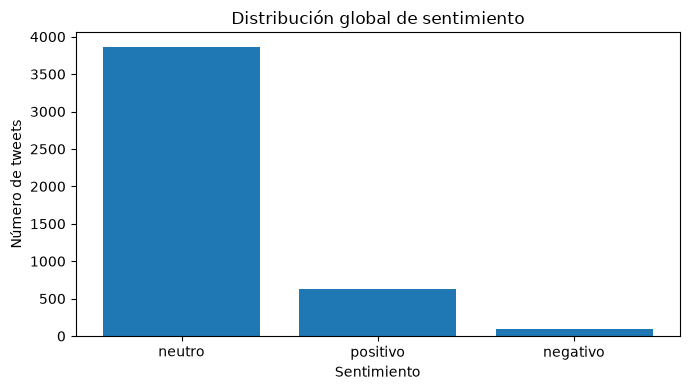

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dist_global["sentimiento_modelo"], dist_global["n"])
ax.set_title("Distribución global de sentimiento")
ax.set_xlabel("Sentimiento")
ax.set_ylabel("Número de tweets")
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "distribucion_clases_sentimiento.png", dpi=150)
plt.show()

## Evolución mensual del sentimiento institucional

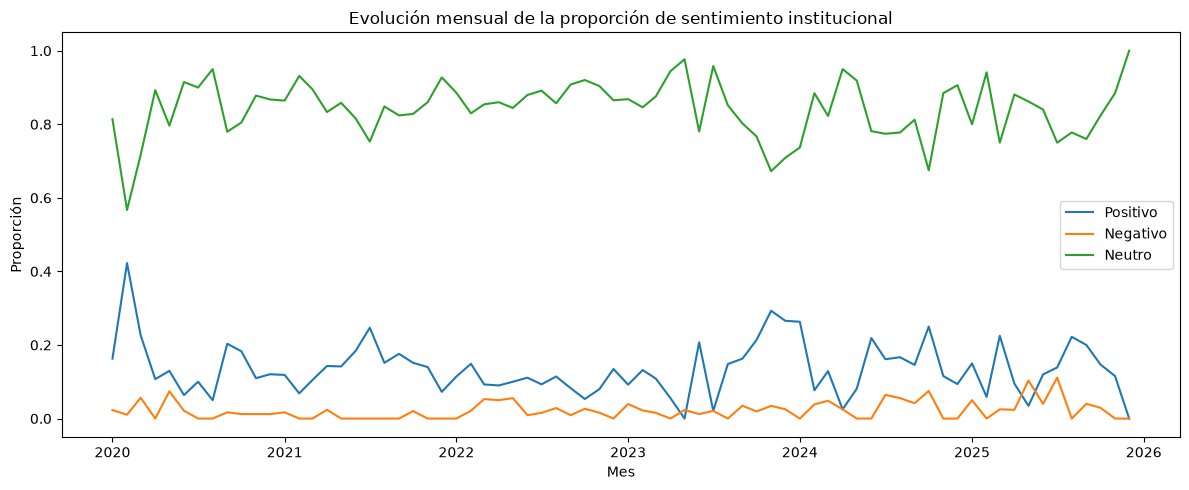

sentimiento_modelo,mes,negativo,neutro,positivo,total,pct_positivo,pct_negativo,pct_neutro
0,2020-01-01,1,35,7,43,0.162791,0.023256,0.813953
1,2020-02-01,1,55,41,97,0.422680,0.010309,0.567010
2,2020-03-01,3,38,12,53,0.226415,0.056604,0.716981
3,2020-04-01,0,25,3,28,0.107143,0.000000,0.892857
4,2020-05-01,4,43,7,54,0.129630,0.074074,0.796296


In [ ]:
mensual = (
    tweets_clasificados
    .pivot_table(index="mes", columns="sentimiento_modelo", values="id", aggfunc="count", fill_value=0)
    .reset_index()
)
for col in ["positivo", "negativo", "neutro"]:
    if col not in mensual.columns:
        mensual[col] = 0
mensual["total"] = mensual[["positivo", "negativo", "neutro"]].sum(axis=1)
mensual["pct_positivo"] = mensual["positivo"] / mensual["total"]
mensual["pct_negativo"] = mensual["negativo"] / mensual["total"]
mensual["pct_neutro"] = mensual["neutro"] / mensual["total"]
mensual.to_csv(OUTPUTS_TABLES / "distribucion_mensual_sentimiento.csv", index=False, encoding="utf-8-sig")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(mensual["mes"], mensual["pct_positivo"], label="Positivo")
ax.plot(mensual["mes"], mensual["pct_negativo"], label="Negativo")
ax.plot(mensual["mes"], mensual["pct_neutro"], label="Neutro")
ax.set_title("Evolución mensual de la proporción de sentimiento institucional")
ax.set_xlabel("Mes")
ax.set_ylabel("Proporción")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUTS_FIG / "evolucion_sentimiento_mensual.png", dpi=150)
plt.show()
display(mensual.head())

## Ejemplos representativos por clase

In [ ]:
ejemplos = (
    tweets_clasificados
    .sort_values("confianza_modelo", ascending=False)
    .groupby("sentimiento_modelo", group_keys=False)
    .head(5)[["id", "fecha_dt", "sentimiento_modelo", "confianza_modelo", "contenido"]]
)
ejemplos.to_csv(OUTPUTS_TABLES / "ejemplos_representativos_sentimiento.csv", index=False, encoding="utf-8-sig")
display(ejemplos)

,id,fecha_dt,sentimiento_modelo,confianza_modelo,contenido
747,1740739390245101800,2023-12-29 14:19:00,positivo,0.953557,Me voy con la sensación de misión cumplida y l...
1037,1701875365730242817,2023-09-13 08:28:00,positivo,0.949344,Lo que estamos construyendo tiene transcendenc...
1214,1666051294484733954,2023-06-06 11:55:00,positivo,0.923643,Nos jugamos mucho con los fondos #NextGenEU. H...
2949,1464010835190333440,2021-11-25 23:19:00,positivo,0.922540,VP @NadiaCalvino en el evento #IngenieroDelAño...
3390,1407772625925988355,2021-06-23 18:48:00,positivo,0.917404,La VP @NadiaCalvino en @Servimedia:\n\nLa cele...
489,1812847813828505607,2024-07-15 13:52:00,negativo,0.916390,Prorrogaremos a 2025 el escudo de Códigos de #...
631,1770088563016691801,2024-03-19 14:02:00,negativo,0.905086,Ejemplos de reclamaciones que atendería la Aut...
4223,1286590255865438208,2020-07-24 09:13:00,neutro,0.904661,En el siguiente mapa disgregamos los datos en ...
3860,1352199028558221314,2021-01-21 10:19:00,negativo,0.898487,La vicepresidenta @NadiaCalvino en el @foroins...
2596,1501954554371444736,2022-03-10 16:14:00,negativo,0.897926,🗣️@PinoCaballero:\n\nSobre los 10 años se prod...


## Nota metodológica

Este enfoque no ofrece métricas supervisadas de rendimiento porque no se dispone de una muestra manual amplia. Esta limitación se compensa con la elección de un modelo preentrenado adecuado para español, el análisis descriptivo de salidas, la revisión cualitativa reducida y la interpretación cautelosa de resultados.